# Day23
31-mar-24

# linear regression example
predict adipost tissue based on waist size

In [5]:
import warnings 
warnings.filterwarnings('ignore')

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 

In [8]:
df=pd.read_csv('WC_AT.csv')
df.head()

,Waist,AT
0,74.75,25.72
1,72.60,25.89
2,81.80,42.60
3,83.95,42.80
4,74.65,29.84


In [29]:
df.describe()

,Waist,AT
count,109.000000,109.000000
mean,91.901835,101.894037
std,13.559116,57.294763
min,63.500000,11.440000
25%,80.000000,50.880000
50%,90.800000,96.540000
75%,104.000000,137.000000
max,121.000000,253.000000


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Waist   109 non-null    float64
 1   AT      109 non-null    float64
dtypes: float64(2)
memory usage: 1.8 KB


In [10]:
df.describe()

,Waist,AT
count,109.000000,109.000000
mean,91.901835,101.894037
std,13.559116,57.294763
min,63.500000,11.440000
25%,80.000000,50.880000
50%,90.800000,96.540000
75%,104.000000,137.000000
max,121.000000,253.000000


In [11]:
df.shape

(109, 2)

### Step 1 - check x can be used to predict Y

#### step 1.1 plot scatter plot and find out coefficient correlation

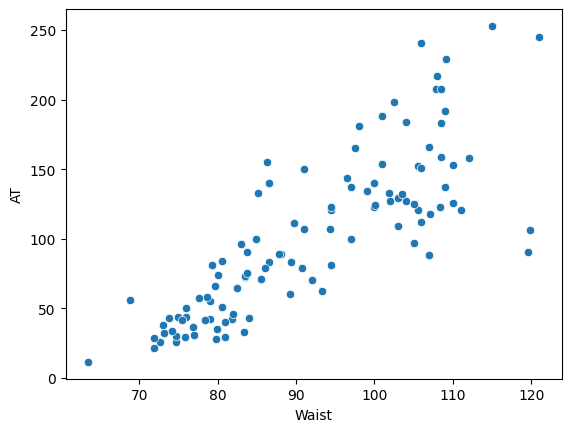

In [19]:
sns.scatterplot(x=df['Waist'],y=df['AT'])
plt.show() 

##### based on above plot we can say that X is correlated(+ve linear relation) with Y(not good relation but not BAd also)

In [22]:
df.corr()

,Waist,AT
Waist,1.000000,0.818558
AT,0.818558,1.000000


##### correlation coefficent ideally it should be >0.85 but 0.81 is also not bad

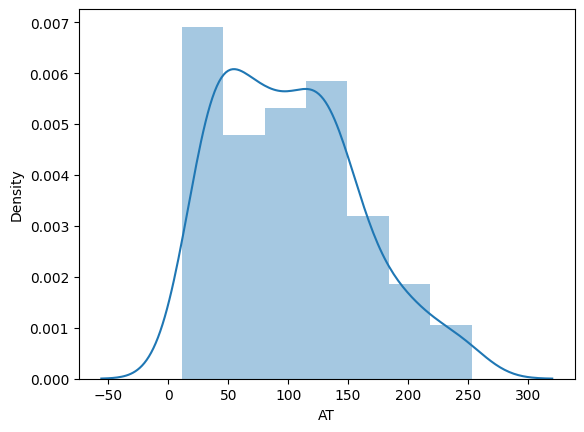

In [25]:
sns.distplot(df['AT'])
plt.show() # distplot - checks the distribution of variable

<Axes: xlabel='AT', ylabel='Count'>

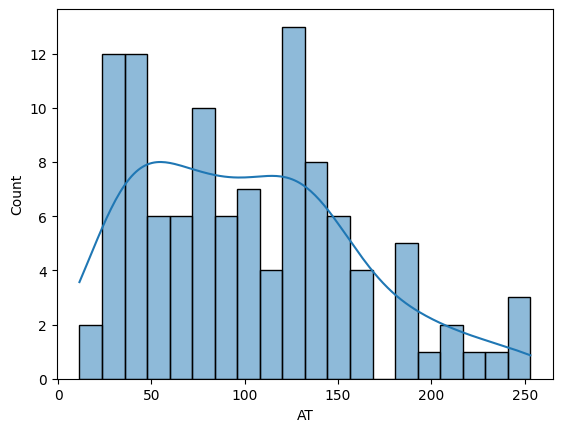

In [27]:
sns.histplot(data=df,x='AT',bins=20,kde=True)

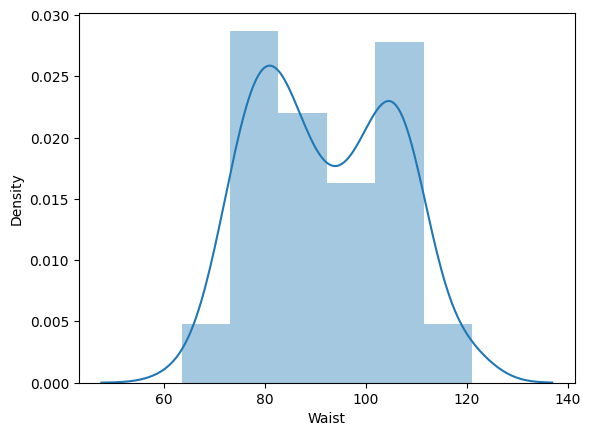

In [33]:
sns.distplot(df['Waist'])
plt.show()

### Step 2 - Build the model

In [36]:
#!conda update scipy statsmodels -y

In [40]:
import statsmodels.formula.api as smf

model = smf.ols("AT~Waist",data=df).fit()
#ols - we are using ols model for bulding the model
#fit() - fit will train the model and estimate the bita((intercept and slope)) values(the fit() function is used to fit the Ordinary Least Squares (OLS) regression model to the data.)
# fit() It calculates the best-fitting line
# "AT~Waist" here AT shoes target vaariable and waist shows dependent variable

<Axes: xlabel='Waist', ylabel='AT'>

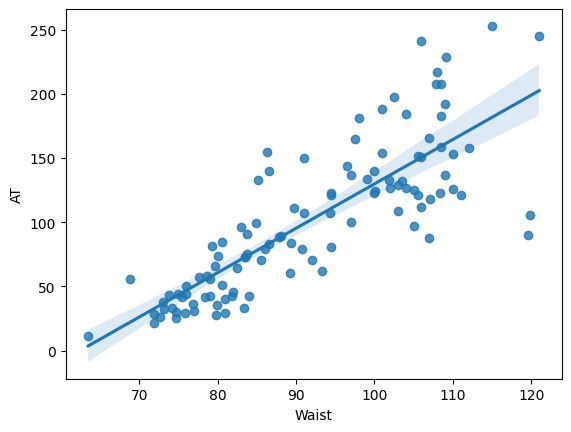

In [42]:
sns.regplot(x='Waist',y='AT',data=df) # plot the regression model. 
# but the best fit line displayed in below plot is not on ythe basis of above calulated values, it is based on method available inside the SNS library

In [55]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     AT   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     217.3
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.62e-27
Time:                        18:00:23   Log-Likelihood:                -534.99
No. Observations:                 109   AIC:                             1074.
Df Residuals:                     107   BIC:                             1079.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -215.9815     21.796     -9.909      0.000    -259.190    -172.773
Waist          3.4589      0.235     14.740      0.000       2.994       3.924
==============================================================================
Omnibus:                        3.960   Durbin-Watson:                   1.560
Prob(Omnibus):                  0.138   Jarque-Bera (JB):                4.596
Skew:                           0.104   Prob(JB):                        0.100
Kurtosis:                       3.984   Cond. No.                         639.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-squared:	0.670 - it is low and it is expoected as we can not explain much variance by using one column
- here if we see p is 0 and which is less than alpha(0.05). here null hypothesis is beta1=0 and Ha is beta1<>0. we are rjecting null hyposthesis.
  it means there is a relattion between waist and Y.

In [62]:
# we can take all parameters seperately also
model.params

Intercept   -215.981488
Waist          3.458859
dtype: float64

In [64]:
model.tvalues

Intercept    -9.909103
Waist        14.740376
dtype: float64

In [66]:
model.rsquared

0.6700368930528429

In [72]:
#model.fstatistic

In [76]:
model.aic

1073.977181831929

In [103]:
model.resid # error - (y-y hat) for each row

0     -16.848252
1      -9.241704
2     -24.353210
3     -31.589758
4     -12.382366
         ...    
104    -6.250337
105   -44.530093
106    -3.130398
107    50.770560
108    48.695244
Length: 109, dtype: float64

In [107]:
model.mse_resid # as it is not standardised we can not directly predict the module by suing this value. so need to go for RMSE

1093.2895889842862

In [117]:
rmse=np.sqrt(model.mse_resid)
print(rmse) # means we are making +-33 error while predicting through model. not good, not bad model

33.06492989534812


In [ ]:
# now we have bult theemodel and ready to predict the AT for any new waist values

### Step 3 - predit Y for new data points

In [89]:
data=[97,103]
data_pred=pd.DataFrame(data,columns=['Waist'])
print(type(data_pred))
print(data_pred)


<class 'pandas.core.frame.DataFrame'>
   Waist
0     97
1    103


In [91]:
# call model and predit the AT for given values
model.predict(data_pred) # model is the name of model created in above problem

0    119.527873
1    140.281029
dtype: float64

In [93]:
data1=[100,150,24,65]
data_pred=pd.DataFrame(data1,columns=['Waist'])
print(type(data_pred))
print(data_pred)

<class 'pandas.core.frame.DataFrame'>
   Waist
0    100
1    150
2     24
3     65


In [95]:
model.predict(data_pred)

0    129.904451
1    302.847421
2   -132.968863
3      8.844373
dtype: float64

In [101]:
# model.predict('100') - not possible to pass direct values, need to pass through the dataframe